In [2]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root1234",
    database="olist_dw"
)

print("Connected successfully")

Connected successfully


In [4]:
# Pull order data from MySQL
query = """
    SELECT
        customer_unique_id,
        order_id,
        order_purchase_date,
        payment_value
    FROM fact_orders
    WHERE order_status = 'delivered'
"""

df = pd.read_sql(query, conn)

print(f"Rows loaded: {len(df)}")
print(df.head())

/var/folders/jj/g9t_hl1s623cr170vqvqj3dm0000gn/T/ipykernel_16455/4219031456.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Rows loaded: 110197
                 customer_unique_id                          order_id  \
0  871766c5855e863f6eccc05f988b23cb  00010242fe8c5a6d1ba2dd792cb16214   
1  eb28e67c4c0b83846050ddfb8a35d051  00018f77f2f0320c557190d7a144bdd3   
2  3818d81c6709e39d06b2738a8d3a2474  000229ec398224ef6ca0657da4fc703e   
3  af861d436cfc08b2c2ddefd0ba074622  00024acbcdf0a6daa1e931b038114c75   
4  64b576fb70d441e8f1b2d7d446e483c5  00042b26cf59d7ce69dfabb4e55b4fd9   

  order_purchase_date  payment_value  
0          2017-09-13          72.19  
1          2017-04-26         259.83  
2          2018-01-14         216.87  
3          2018-08-08          25.78  
4          2017-02-04         218.04  


In [5]:
import datetime

# Reference date — day after last order in dataset
ref_date = datetime.date(2018, 9, 1)

# Convert date column to date type
df['order_purchase_date'] = pd.to_datetime(df['order_purchase_date']).dt.date

# Calculate RFM metrics per customer
rfm = df.groupby('customer_unique_id').agg(
    recency_days=('order_purchase_date', lambda x: (ref_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print(f"Customers: {len(rfm)}")
print(rfm.head())

Customers: 93358
                 customer_unique_id  recency_days  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2           114          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f           117          1     27.19
2  0000f46a3911fa3c0805444483337064           540          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078           324          1     43.62
4  0004aac84e0df4da2b147fca70cf8255           291          1    196.89


In [6]:
# Assign R, F, M scores using quintiles (1-5)
rfm['r_score'] = pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])

# Convert to integer
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

# Assign segments
def assign_segment(row):
    r, f = row['r_score'], row['f_score']
    m = row['m_score']
    if r >= 4 and f >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['segment'].value_counts())

segment
Potential Loyalist    22421
At Risk               22154
Loyal                 18852
Champion              15009
Cant Lose Them         8658
Lost                   6264
Name: count, dtype: int64


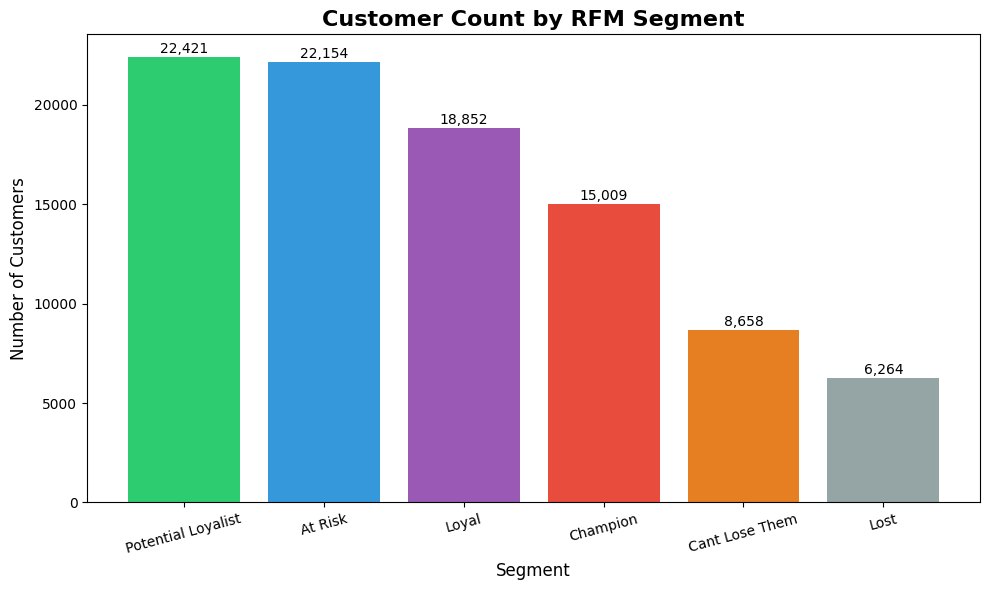

Chart 1 saved


In [7]:
# Chart 1: Customer count by segment
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_monetary=('monetary', 'mean'),
    avg_recency=('recency_days', 'mean')
).reset_index().sort_values('customer_count', ascending=False)

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#e67e22', '#95a5a6']

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_summary['segment'], segment_summary['customer_count'], color=colors)
plt.title('Customer Count by RFM Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=15)

for bar, val in zip(bars, segment_summary['customer_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/vaibhavviraj/Desktop/rfm_segment_distribution.png', dpi=150)
plt.show()
print("Chart 1 saved")

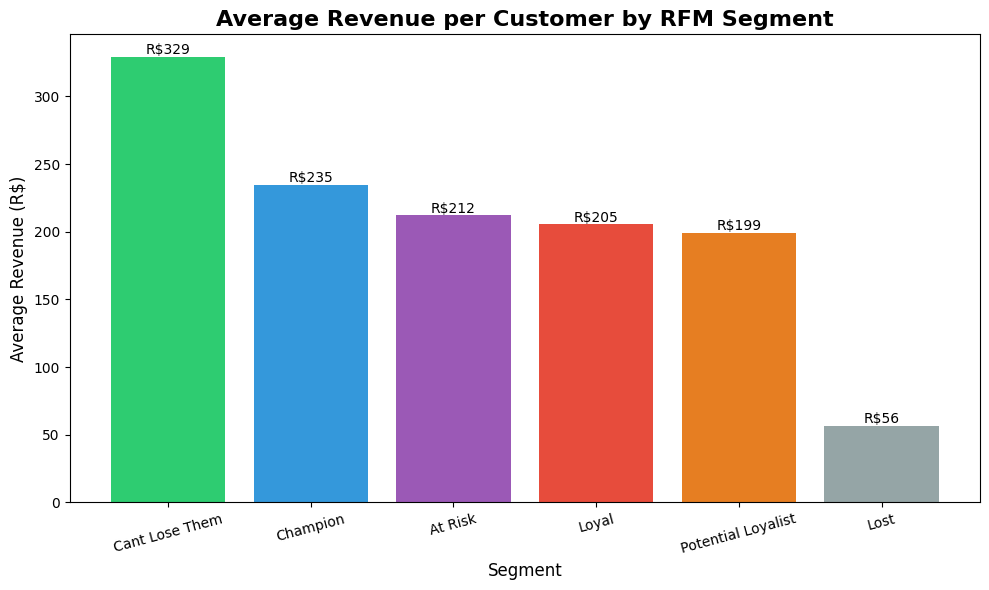

Chart 2 saved


In [8]:
# Chart 2: Average monetary value by segment
segment_summary_sorted = segment_summary.sort_values('avg_monetary', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_summary_sorted['segment'], 
               segment_summary_sorted['avg_monetary'].round(2), 
               color=colors)
plt.title('Average Revenue per Customer by RFM Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Average Revenue (R$)', fontsize=12)
plt.xticks(rotation=15)

for bar, val in zip(bars, segment_summary_sorted['avg_monetary']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'R${val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/vaibhavviraj/Desktop/rfm_avg_revenue.png', dpi=150)
plt.show()
print("Chart 2 saved")

In [9]:
# Export RFM segmentation to CSV for Power BI
rfm.to_csv('/Users/vaibhavviraj/Desktop/rfm_segments.csv', index=False)

print(f"Exported {len(rfm)} rows to rfm_segments.csv")
print("\nSegment summary:")
print(rfm.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    avg_revenue=('monetary', 'mean'),
    avg_recency=('recency_days', 'mean')
).round(2).sort_values('customers', ascending=False))

Exported 93358 rows to rfm_segments.csv

Segment summary:
                    customers  avg_revenue  avg_recency
segment                                                
Potential Loyalist      22421       199.44       136.46
At Risk                 22154       212.21       397.63
Loyal                   18852       205.49       171.74
Champion                15009       234.77        93.05
Cant Lose Them           8658       329.43       398.20
Lost                     6264        56.40       399.14
